# Initial Setup

In [37]:
%pip install catboost lightgbm optuna holidays duckdb

## Imports

In [38]:
import numpy as np
import pandas as pd
import duckdb

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, TimeSeriesSplit, cross_val_predict, cross_val_score, cross_validate
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.base import clone
from sklearn.compose import ColumnTransformer

from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

import lightgbm as lgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor, Pool

import optuna
from typing import Any
import warnings

import holidays

## Variables

In [39]:
def check_environment():
    try:
        import google.colab
        env = "colab"
    except ImportError:
        env = "local"
    return env

ENVIRONMENT = check_environment()

DRIVE_FOLDER_NAME = "Store Sales"

In [40]:
import plotly.io as pio
pio.renderers.default = "vscode"

In [41]:
TARGET = "sales"
N_SPLITS = 5
SEED = 42
eps = 1e-5

def check_environment():
    try:
        import google.colab
        env = "colab"
    except ImportError:
        env = "local"
    return env

ENVIRONMENT = check_environment()

non_relevant_columns = ['id', 'source']


## Helper Functions

### Data Loader

In [42]:
def load_data(option: str="local"):
  '''
  returns train_df, test_df, df

  '''
  if option == "local":
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')

  elif option == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    train_df = pd.read_csv(f'/content/drive/MyDrive/Kaggle Practice/{DRIVE_FOLDER_NAME}/train.csv')
    test_df = pd.read_csv(f'/content/drive/MyDrive/Kaggle Practice/{DRIVE_FOLDER_NAME}/test.csv')

  train_df['source'] = 'train'
  test_df['source'] = 'test'
  train_df['date'] =  pd.to_datetime(train_df['date'])
  test_df['date'] =  pd.to_datetime(test_df['date'])
  df = pd.concat([train_df, test_df], ignore_index=True)

  return train_df, test_df, df

### Loader of additional data

In [43]:
def load_helper_data(option: str="local"):
  '''
  returns oil_df, transactions_df, holidays_events_df, stores_df

  '''
  if option == "local":
    oil_df = pd.read_csv('oil.csv')
    transactions_df = pd.read_csv('transactions.csv')
    holidays_events_df = pd.read_csv('holidays_events.csv')
    stores_df = pd.read_csv('stores.csv')


  elif option == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    oil_df = pd.read_csv(f'/content/drive/MyDrive/Kaggle Practice/{DRIVE_FOLDER_NAME}/oil.csv')
    transactions_df = pd.read_csv(f'/content/drive/MyDrive/Kaggle Practice/{DRIVE_FOLDER_NAME}/transactions.csv')
    holidays_events_df = pd.read_csv(f'/content/drive/MyDrive/Kaggle Practice/{DRIVE_FOLDER_NAME}/holidays_events.csv')
    stores_df = pd.read_csv(f'/content/drive/MyDrive/Kaggle Practice/{DRIVE_FOLDER_NAME}/stores.csv')
    
  oil_df['date'] =  pd.to_datetime(oil_df['date'])
  transactions_df['date'] =  pd.to_datetime(transactions_df['date'])
  holidays_events_df['date'] =  pd.to_datetime(holidays_events_df['date'])
  


  return oil_df, transactions_df, holidays_events_df, stores_df

### Data Splitter

In [44]:
def data_splitter(df: pd.DataFrame, additional_drop_columns: list = []) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame]:
    '''
    return: X_train, y_train, submission_df

    '''
    train_dataset = df[df['source'] == 'train'].drop(columns=non_relevant_columns + additional_drop_columns)
    submission_dataset = df[df['source'] == 'test'].drop(columns=['source', TARGET] + additional_drop_columns)

    X_train = train_dataset.drop(columns=[TARGET])
    y_train = train_dataset[TARGET]

    return X_train, y_train, submission_dataset

## Create DataFrames

In [45]:
train_df, test_df, df = load_data(ENVIRONMENT)
oil_df, transactions_df, holidays_events_df, stores_df = load_helper_data(ENVIRONMENT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Tables infos

## Overall Info

### Main DF

In [0]:
df.head()

In [0]:
df.groupby('source').agg(min_date=('date', 'min'), max_date=('date', 'max'))

In [0]:
df.describe(include='all')

### Stores

In [0]:
stores_df.head()

In [0]:
stores_df.describe(include='all')

### Transactions

In [0]:
transactions_df.head()

In [0]:
transactions_df.describe(include='all')

### Holidays

In [0]:
holidays_events_df.head()

In [0]:
holidays_events_df.describe()

### Oil

In [0]:
oil_df.head()

In [0]:
oil_df.describe()

In [0]:
df.head()

# Merging datasets

In [46]:
is_transferred = holidays_events_df['transferred'] == True
legit_holidays = holidays_events_df['type'].isin(['Holiday', 'Transfer', 'Bridge', 'Additional'])
is_workday = holidays_events_df['type']  == 'Work Day'
is_event = holidays_events_df['type']  == 'Event'

is_national = holidays_events_df['locale'] == 'National'
is_regional = holidays_events_df['locale'] == 'Regional'
is_local = holidays_events_df['locale'] == 'Local'

national_holidays = holidays_events_df.loc[(~is_transferred) & (is_national) & (legit_holidays)]
regional_holidays = holidays_events_df.loc[(~is_transferred) & (is_regional) & (legit_holidays)]
local_holidays = holidays_events_df.loc[(~is_transferred) & (is_local) & (legit_holidays)]

In [47]:
is_transferred = holidays_events_df['transferred'] == True
legit_holidays = holidays_events_df['type'].isin(['Holiday', 'Transfer', 'Bridge', 'Additional'])
is_workday = holidays_events_df['type']  == 'Work Day'
is_event = holidays_events_df['type']  == 'Event'

is_national = holidays_events_df['locale'] == 'National'
is_regional = holidays_events_df['locale'] == 'Regional'
is_local = holidays_events_df['locale'] == 'Local'

national_holidays = holidays_events_df.loc[(~is_transferred) & (is_national) & (legit_holidays)]
regional_holidays = holidays_events_df.loc[(~is_transferred) & (is_regional) & (legit_holidays)]
local_holidays = holidays_events_df.loc[(~is_transferred) & (is_local) & (legit_holidays)]

national_holidays = national_holidays.groupby('date').agg(nat_num_holidays=('type', 'count'), nat_holiday_types =('type', ', '.join)).sort_values(by='nat_num_holidays', ascending=False).reset_index()
national_holidays['is_national'] = 1

regional_holidays = regional_holidays.groupby(['date', 'locale_name']).agg(reg_num_holidays=('type', 'count'), reg_holiday_types =('type', ', '.join)).sort_values(by='reg_num_holidays', ascending=False).reset_index()
regional_holidays['is_regional'] = 1

local_holidays = local_holidays.groupby(['date', 'locale_name']).agg(loc_num_holidays=('type', 'count'), local_holiday_types =('type', ', '.join)).sort_values(by='loc_num_holidays', ascending=False).reset_index()
local_holidays['is_local'] = 1


workdays = holidays_events_df.loc[(~is_transferred) & (is_workday)].copy()
workdays['is_workday'] = 1
workdays = workdays[['date', 'is_workday']].drop_duplicates(subset=['date'], keep='first')

events = holidays_events_df.loc[(~is_transferred) & (is_event)].copy()
events['is_event'] = 1
events = events[['date', 'is_event']].drop_duplicates(subset=['date'], keep='first')

In [48]:
initial_length = len(df)

oil_df = (oil_df.set_index("date")
                .reindex(pd.date_range(oil_df["date"].min(), df["date"].max()))
                .ffill().bfill()
                .rename_axis("date").reset_index())

df = (df.merge(transactions_df, on=['date', 'store_nbr'], how='left')
            .merge(stores_df, on='store_nbr', how='left')
            .merge(oil_df, on='date', how='left')
            .merge(national_holidays, on='date', how='left')
            .merge(regional_holidays, left_on=['date', 'state'], right_on=['date','locale_name'], how='left').drop(columns=['locale_name'])
            .merge(local_holidays, left_on=['date','city'], right_on=['date','locale_name'], how='left').drop(columns=['locale_name'])
            .merge(workdays, on='date', how='left')
						.merge(events, on='date', how='left')
            )

In [49]:
final_length = len(df)

In [50]:
assert initial_length == final_length, 'Length is not matching'

In [51]:
df.loc[df['source'] == 'train'].isna().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0
source,0
transactions,245784
city,0
state,0


## Null Adjustments

In [52]:
is_train = df["sales"].notna()

df["store_sales"] = df.groupby(["date", "store_nbr"])["sales"].transform("sum")

transaction_null = df["transactions"].isna()
store_closed = df["store_sales"] == 0

df.loc[is_train & transaction_null & store_closed, "transactions"] = 0

In [53]:
num_holiday_cols = ['is_national', 'is_regional', 'is_local', 'is_workday', 'is_event', 'nat_num_holidays', 'reg_num_holidays', 'loc_num_holidays']
str_holiday_cols = ['nat_holiday_types', 'reg_holiday_types', 'local_holiday_types']

df[num_holiday_cols] = df[num_holiday_cols].fillna(0).astype(int)
df[str_holiday_cols] = df[str_holiday_cols].fillna('none')

In [54]:
df.loc[df['source'] == 'train'].isna().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0
source,0
transactions,3894
city,0
state,0


# EDA

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3029400 entries, 0 to 3029399
Data columns (total 25 columns):
 #   Column               Dtype         
---  ------               -----         
 0   id                   int64         
 1   date                 datetime64[ns]
 2   store_nbr            int64         
 3   family               object        
 4   sales                float64       
 5   onpromotion          int64         
 6   source               object        
 7   transactions         float64       
 8   city                 object        
 9   state                object        
 10  type                 object        
 11  cluster              int64         
 12  dcoilwtico           float64       
 13  nat_num_holidays     int64         
 14  nat_holiday_types    object        
 15  is_national          int64         
 16  reg_num_holidays     int64         
 17  reg_holiday_types    object        
 18  is_regional          int64         
 19  loc_num_holidays     

In [27]:
df.describe(include='object').T

,count,unique,top,freq
family,3029400,33,AUTOMOTIVE,91800
source,3029400,2,train,3000888
city,3029400,22,Quito,1009800
state,3029400,16,Pichincha,1065900
type,3029400,5,D,1009800
nat_holiday_types,3029400,6,none,2890404
reg_holiday_types,3029400,2,none,3028377
local_holiday_types,3029400,5,none,3017454


In [28]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
id,3029400.0,1.514700e+06,874512.597080,0.00,757349.7500,1.514700e+06,2.272049e+06,3029399.000
store_nbr,3029400.0,2.750000e+01,15.585787,1.00,14.0000,2.750000e+01,4.100000e+01,54.000
sales,3000888.0,3.577757e+02,1101.997721,0.00,0.0000,1.100000e+01,1.958473e+02,124717.000
onpromotion,3029400.0,2.643830e+00,12.332875,0.00,0.0000,0.000000e+00,0.000000e+00,741.000
transactions,2996994.0,1.557829e+03,1032.514736,0.00,932.0000,1.332000e+03,1.978000e+03,8359.000
cluster,3029400.0,8.481481e+00,4.649735,1.00,4.0000,8.500000e+00,1.300000e+01,17.000
dcoilwtico,3029400.0,6.773231e+01,25.624450,26.19,46.4075,5.328000e+01,9.571000e+01,110.620
nat_num_holidays,3029400.0,4.647059e-02,0.213278,0.00,0.0000,0.000000e+00,0.000000e+00,2.000
is_national,3029400.0,4.588235e-02,0.209230,0.00,0.0000,0.000000e+00,0.000000e+00,1.000
reg_num_holidays,3029400.0,3.376906e-04,0.018373,0.00,0.0000,0.000000e+00,0.000000e+00,1.000


In [29]:
df.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'source',
       'transactions', 'city', 'state', 'type', 'cluster', 'dcoilwtico',
       'nat_num_holidays', 'nat_holiday_types', 'is_national',
       'reg_num_holidays', 'reg_holiday_types', 'is_regional',
       'loc_num_holidays', 'local_holiday_types', 'is_local', 'is_workday',
       'is_event', 'store_sales'],
      dtype='object')

## Store Nbr

<Axes: xlabel='store_nbr', ylabel='store_sales'>

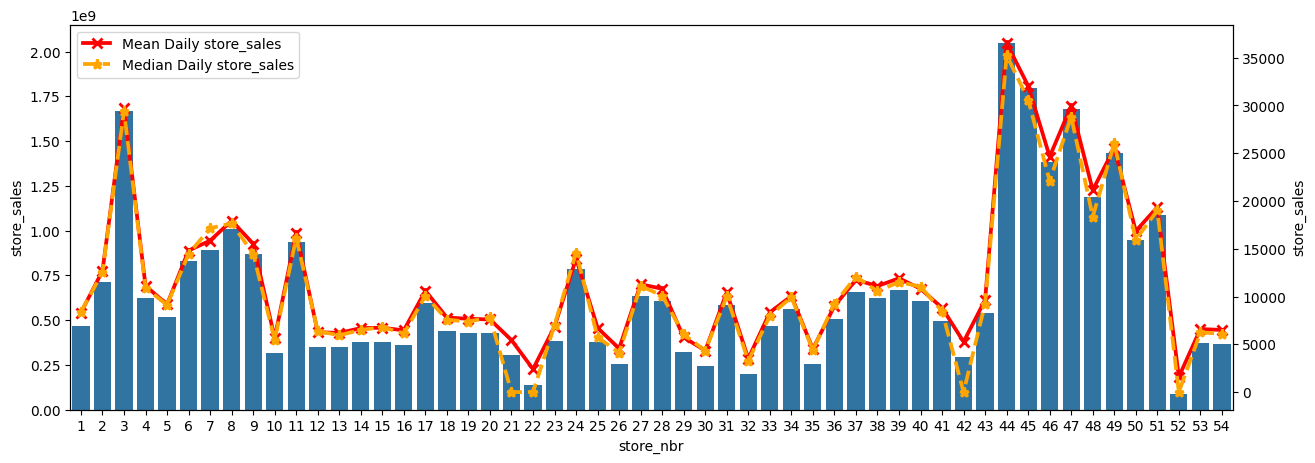

In [30]:
plt.figure(figsize=(15,5))
ax1 = sns.barplot(
    df,
    x='store_nbr',
    y='store_sales',
    estimator='sum',
    errorbar=None,
)

ax2 = ax1.twinx()

sns.pointplot(
    data=df,
    x='store_nbr',
    y='store_sales',
    estimator='mean',
    ax=ax2,
    color='red',
    markers='x',
    linestyles='-',
    label="Mean Daily store_sales",
)


sns.pointplot(
    data=df,
    x='store_nbr',
    y='store_sales',
    estimator='median',
    ax=ax2,
    color='orange',
    markers='*',
    linestyles='--',
    label = "Median Daily store_sales",
)

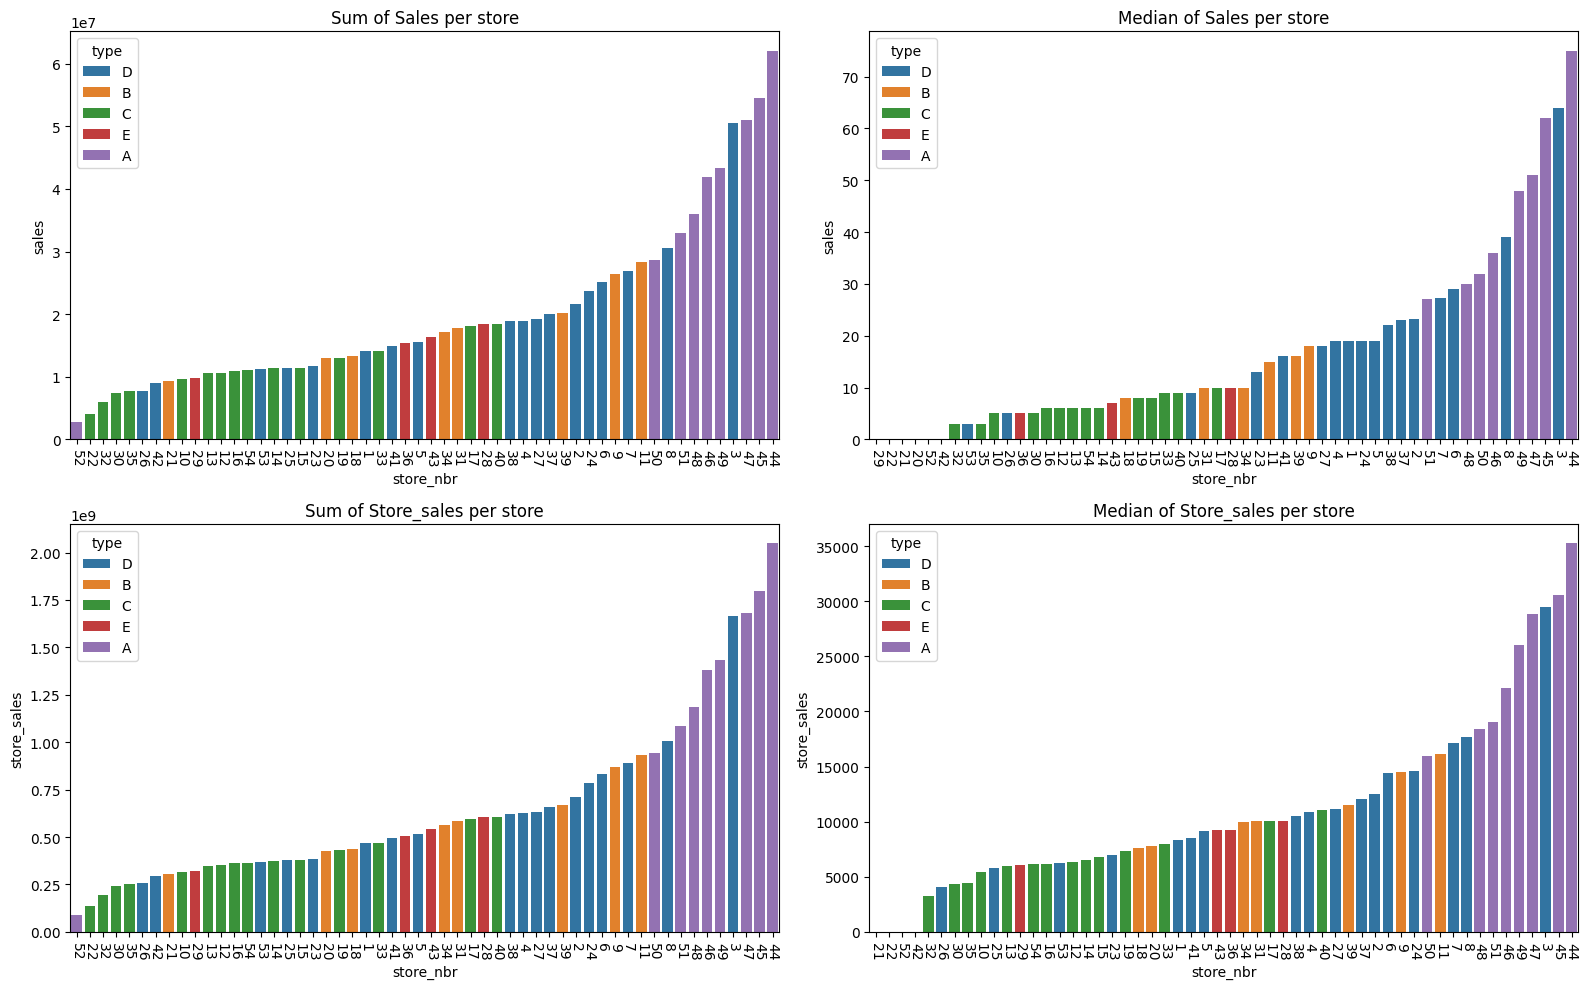

In [31]:
col, metric = ["sales", "store_sales"], ["sum", "median"]

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
for i, c in enumerate(col):         # i -> row
    for j, m in enumerate(metric): # j - column
        order = df.groupby("store_nbr")[c].agg(m).sort_values().index
        plot_ax = axs[i,j]
        sns.barplot(
            df,
            x="store_nbr",
            y=c,
            estimator=m,
            errorbar=None,
            ax=plot_ax,
            order=order,
            hue='type'
            
        )
        plot_ax.set_title(f"{m.capitalize()} of {c.capitalize()} per store")
        plot_ax.tick_params(axis="x", rotation=270)
plt.tight_layout()

In [32]:
stats = df.groupby("store_nbr")['sales'].agg(median = 'median').reset_index()
zero_median = stats['median'] == 0
stats.loc[zero_median, 'median_sales'] = 'Zero'

stats.loc[~zero_median,'median_sales'] = pd.qcut(
        stats.loc[~zero_median,'median'],
        q=6,
        labels=['Low', 'Lower-mid', 'Mid', 'Upper-mid', 'High', 'Top']
)

stats.sort_values(by='median')

,store_nbr,median,median_sales
28,29,0.0000,Zero
21,22,0.0000,Zero
20,21,0.0000,Zero
19,20,0.0000,Zero
51,52,0.0000,Zero
41,42,0.0000,Zero
31,32,3.0000,Low
52,53,3.0000,Low
34,35,3.0000,Low
9,10,5.0000,Low


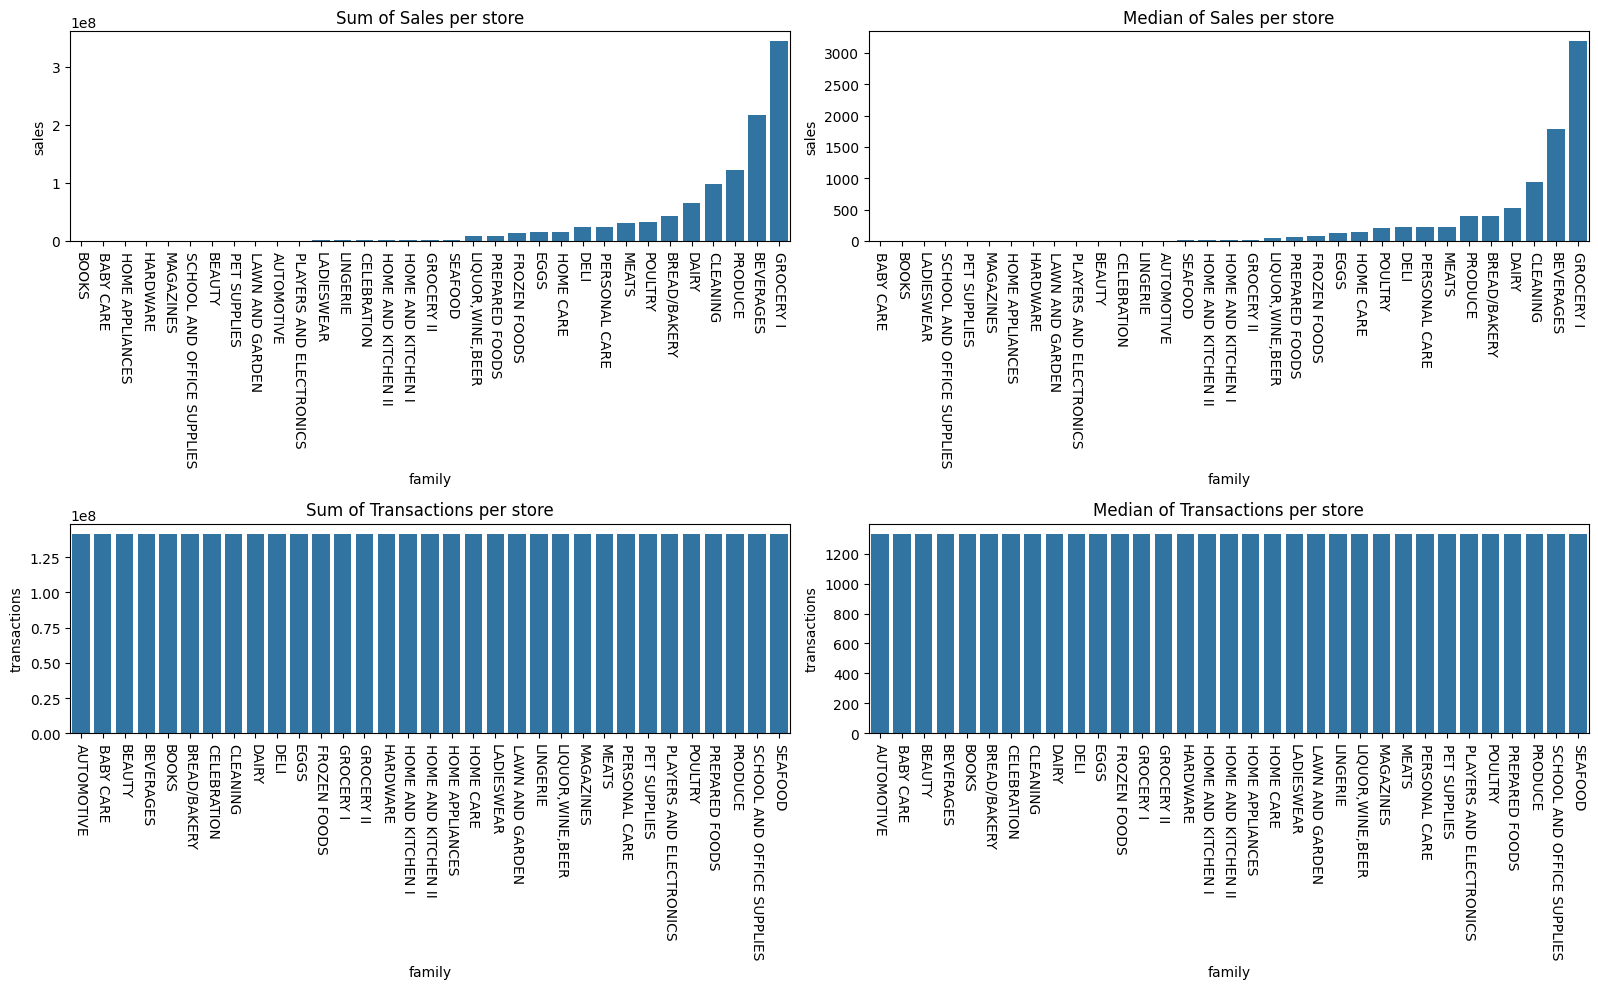

In [36]:
col, metric = ["sales", "transactions"], ["sum", "median"]

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
for i, c in enumerate(col):         # i -> row
    for j, m in enumerate(metric): # j - column
        order = df.groupby("family")[c].agg(m).sort_values().index
        plot_ax = axs[i,j]
        sns.barplot(
            df,
            x="family",
            y=c,
            estimator=m,
            errorbar=None,
            ax=plot_ax,
            order=order,
            
        )
        plot_ax.set_title(f"{m.capitalize()} of {c.capitalize()} per store")
        plot_ax.tick_params(axis="x", rotation=270)
plt.tight_layout()

In [69]:
store_family_summary = df.groupby(["store_nbr", "family"]).agg(
    sum_sales=("sales", "sum"),
    median_sales=("sales", "median"),
    average_sales=("sales", "mean"),
).reset_index().pivot(
    index='family',
    columns='store_nbr',
    values=['sum_sales', 'median_sales', 'average_sales']
)

In [ ]:
# order = store_family_summary['sum_sales'].sum(axis=1).sort_values(ascending=False).index
# store_family_summary = store_family_summary['sum_sales'].loc[order]

KeyError: 'sum_sales'

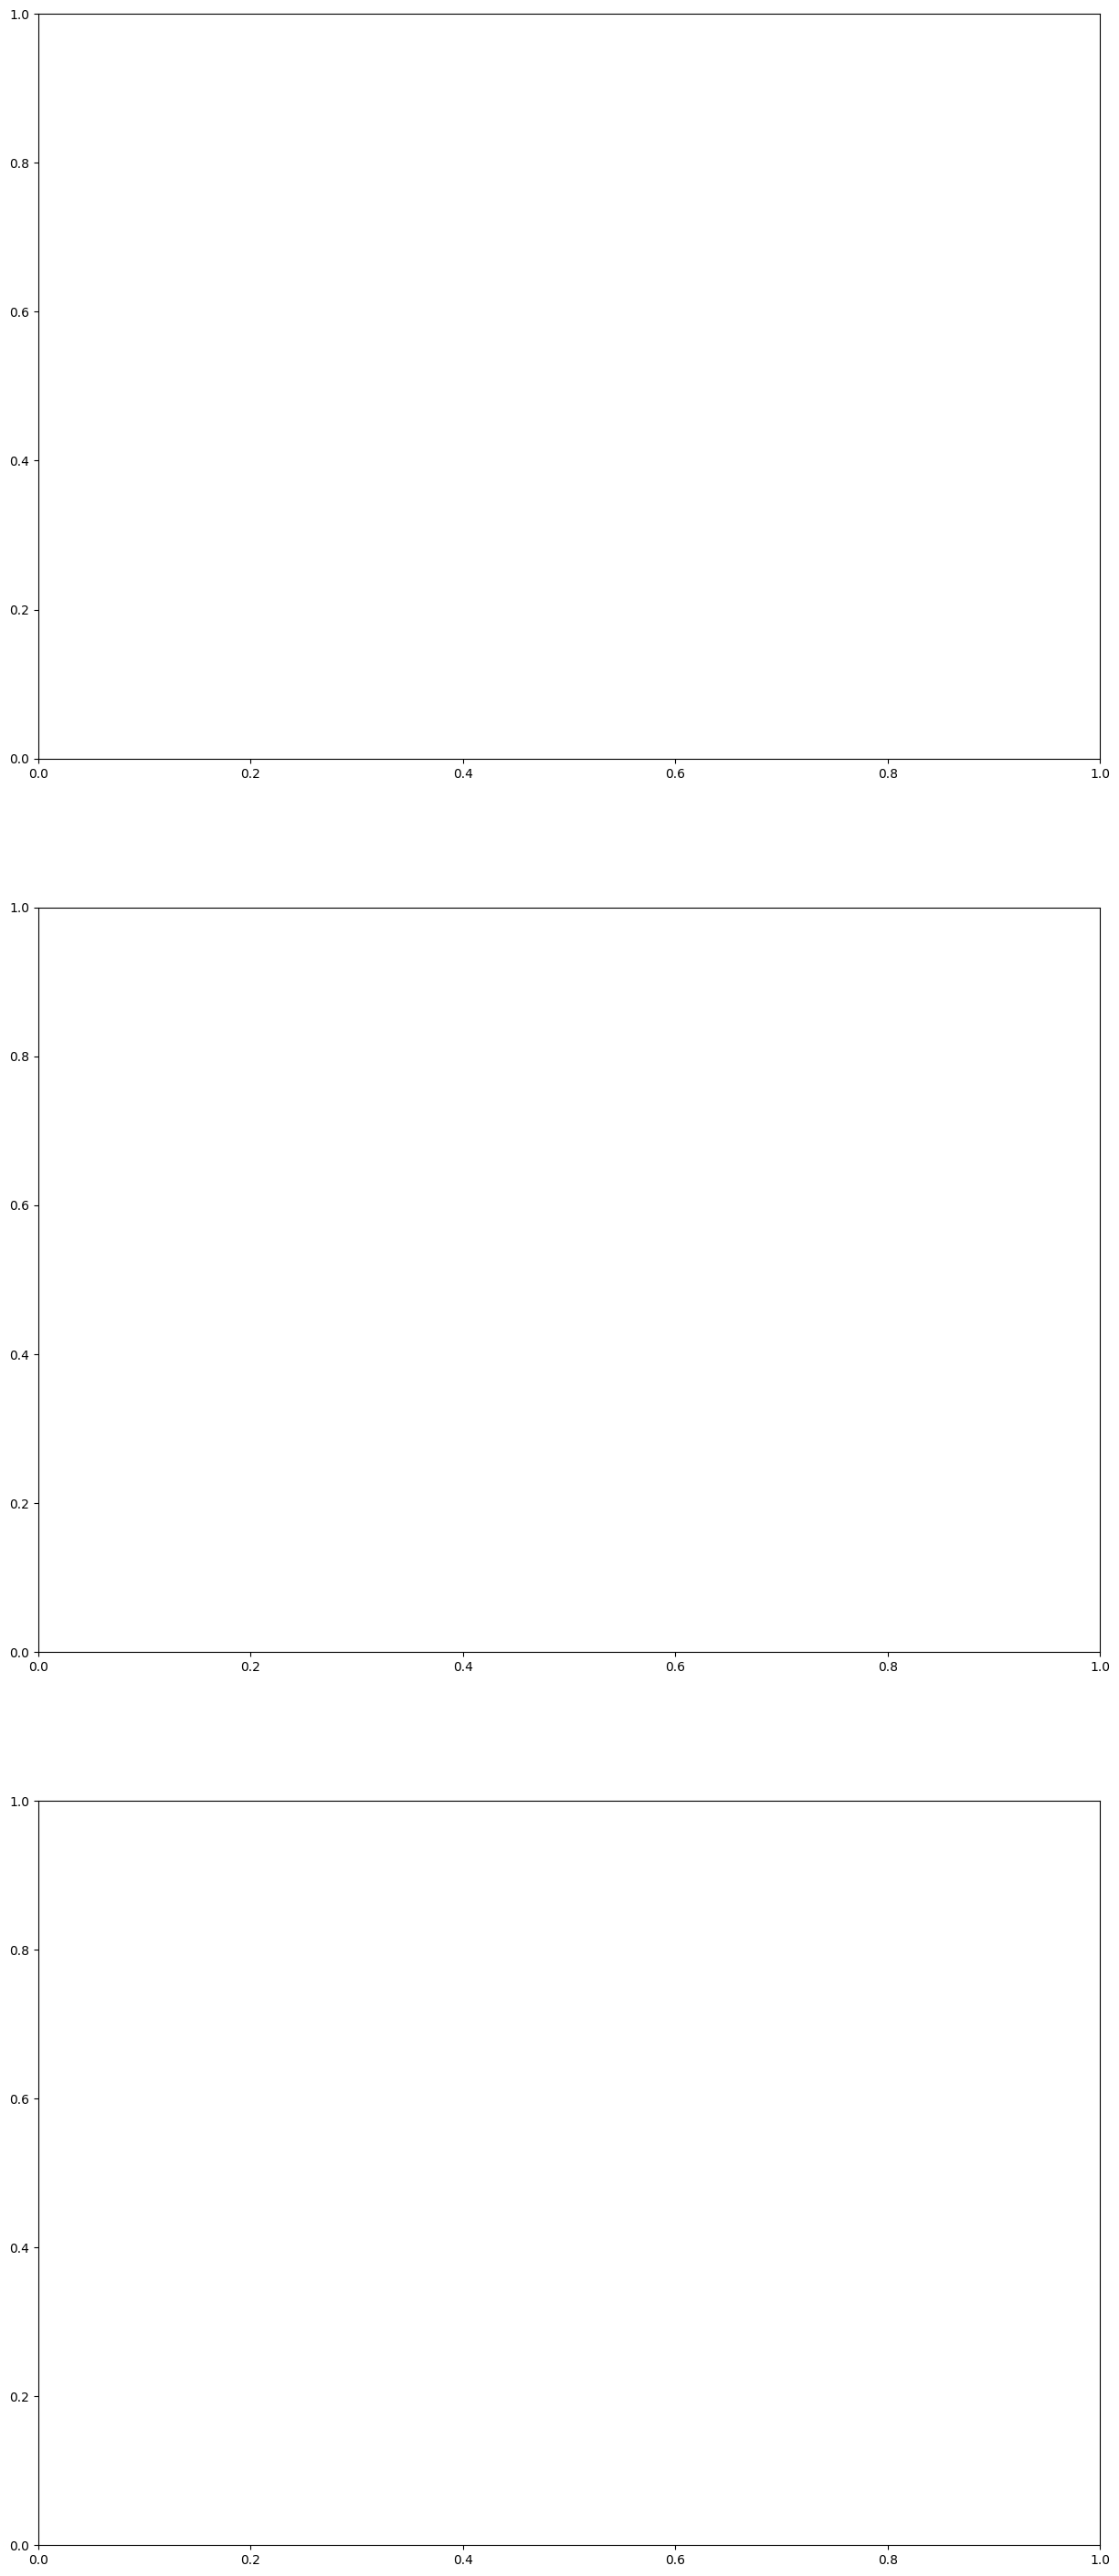

In [ ]:
fig, axs = plt.subplots(3,1,figsize=(15,36))
values=['sum_sales', 'median_sales', 'average_sales']

for i, v in enumerate(values):
	order = store_family_summary[v].sum(axis=1).sort_values(ascending=False).index
	heatmap_df = store_family_summary[v].loc[order]

	sns.heatmap(
			store_family_summary,
			# annot=True,
			fmt=f",.0f",
			cmap="YlGnBu",
			linewidths=0.2,
			annot_kws={"size": 7},
			square=True,
			robust=True,
			cbar_kws={"shrink": 0.4, "aspect": 30, "pad": 0.01},
			ax=axs[i,0]
	)

	axs[i,0].xaxis.tick_top()
	axs[i,0].xaxis.set_label_position('top')

plt.tight_layout()

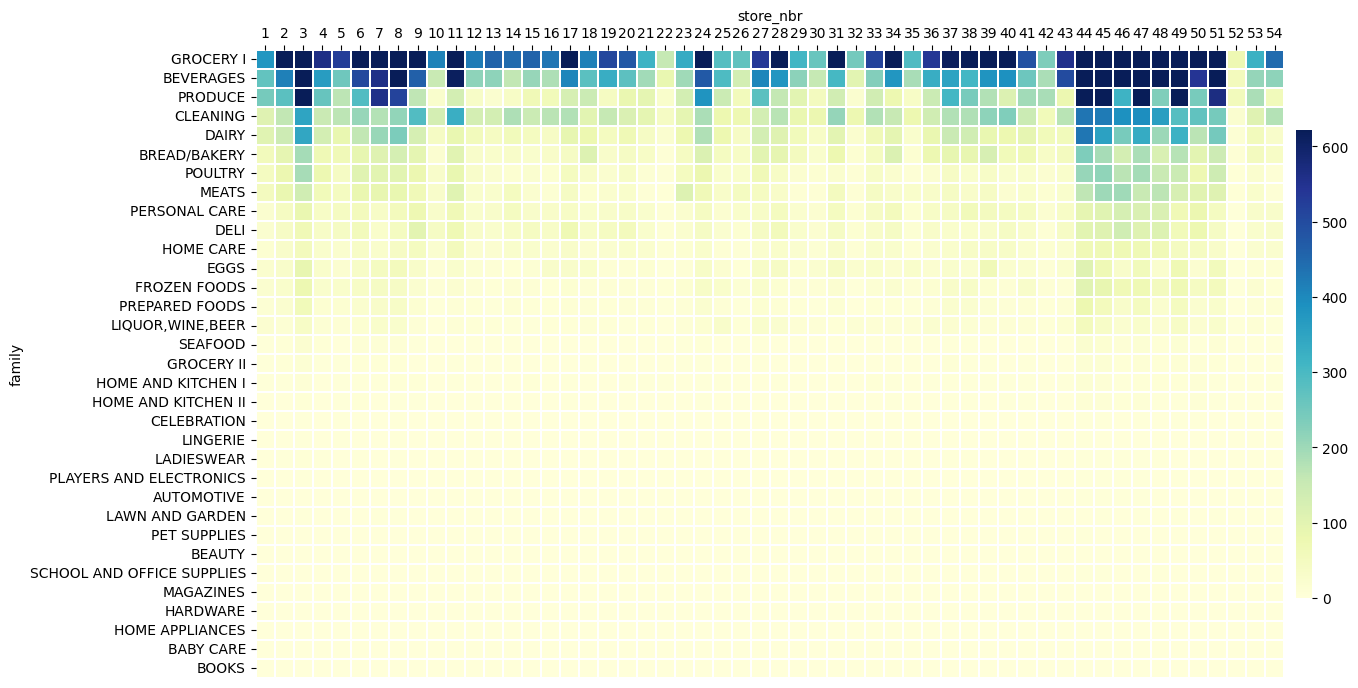

In [58]:
plt.figure(figsize=(15,12))
ax = sns.heatmap(
    store_family_summary/ 10000,
    # annot=True,
    fmt=f",.0f",
    cmap="YlGnBu",
    linewidths=0.2,
    annot_kws={"size": 7},
    square=True,
    robust=True,
    cbar_kws={"shrink": 0.4, "aspect": 30, "pad": 0.01},  
)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.tight_layout()

# Feature Engineering